In [ ]:
import os
import numpy as np
import pandas as pd

# =========================
# User settings
# =========================
site = "_LA"                 # e.g. _SA, _LA ...
tas_data_path = "site_data"
downscaled = False           # Set to True if downscaled data is used, False otherwise

# site = "34"                 # e.g. _SA, _LA ...
# tas_data_path = "../results_on_sites/high_reso_sites"
# downscaled = True            # Set to True if downscaled data is used, False otherwise

member_idx = 66               # Lord et al. member (67th, 0-based)
gsl_thresholds = [-93.0, -53.0]

# If naturagsl/ssp126gsl... are not already in memory, load GSL from CGSLM inputs:
cgslm_results_path = "../2_GSL_model/results/emul_inputs_updatedCO2"
use_preloaded_gsl_if_available = True
n_members_expected = 90

# Scenario naming used in tas files and CGSLM file names
scenarios = ["natural", "SSP126", "SSP245", "SSP370", "SSP585", "10000PGC"]


def _read_cgslm_member_series(base_path, scenario_name, member_i):
    """Read one member file and return ice (GSL) time series as float array."""
    candidates = [
        f"emul_inputs_{scenario_name}.{member_i}.updated.res",
        f"emul_inputs_{scenario_name.upper()}.{member_i}.updated.res",
        f"emul_inputs_{scenario_name.lower()}.{member_i}.updated.res",
        f"emul_inputs_10000PGC.{member_i}.updated.res" if scenario_name.lower() == "10000pgc" else None,
    ]
    candidates = [c for c in candidates if c is not None]

    for name in candidates:
        fp = os.path.join(base_path, name)
        if os.path.exists(fp):
            df = pd.read_csv(fp, header=0, sep=r"\s+")
            if "ice" not in df.columns:
                raise KeyError(f"Column 'ice' not found in {fp}")
            return df["ice"].to_numpy(dtype=float)

    raise FileNotFoundError(
        f"No CGSLM file found for scenario={scenario_name}, member={member_i} in {base_path}"
    )


def load_gsl_for_scenario(scenario_name):
    """Return GSL array with shape [member, time]."""
    loaded = []
    for member in range(1, n_members_expected + 1):
        loaded.append(_read_cgslm_member_series(cgslm_results_path, scenario_name, member))
    return np.asarray(loaded, dtype=float)


def build_gsl_by_scenario():
    """Use preloaded variables when available; otherwise load from files."""
    preloaded = {
        "natural": "naturagsl",
        "SSP126": "ssp126gsl",
        "SSP245": "ssp245gsl",
        "SSP370": "ssp370gsl",
        # "SSP460": "ssp460gsl",
        # "SSP534": "ssp534gsl",
        "SSP585": "ssp585gsl",
        "10000PGC": "pgc10000gsl",
    }

    out = {}
    for scen in scenarios:
        var_name = preloaded.get(scen)
        if use_preloaded_gsl_if_available and var_name in globals():
            out[scen] = np.asarray(globals()[var_name], dtype=float)
        else:
            out[scen] = load_gsl_for_scenario(scen)
    return out


def _ensure_member_time(arr, n_members_hint=90):
    """Normalize 2D arrays to [members, time]."""
    arr = np.asarray(arr, dtype=float)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D tas array, got shape={arr.shape}")

    # Preferred explicit detection with member-count hint.
    if arr.shape[0] == n_members_hint and arr.shape[1] != n_members_hint:
        return arr
    if arr.shape[1] == n_members_hint and arr.shape[0] != n_members_hint:
        return arr.T

    # Fallback when member hint is not decisive.
    if arr.shape[0] <= arr.shape[1]:
        return arr
    return arr.T


def load_tas_for_scenario(scenario_name, site_name):
    """Return tas array with shape [member, time]."""
    if downscaled:    
        candidates = [
            f"site_{site_name}/tas_{scenario_name}_UK_site{site_name}.txt",
            f"site_{site_name}/tas_{scenario_name.upper()}_UK_site{site_name}.txt",
            f"site_{site_name}/tas_{scenario_name.lower()}_UK_site{site_name}.txt",
            f"site_{site_name}/tas_10000PGC_UK_site{site_name}.txt" if scenario_name.lower() == "10000pgc" else None,
        ]
    else:
        candidates = [
            f"site{site_name}/tas_{scenario_name}_site{site_name}.txt",
            f"site{site_name}/tas_{scenario_name.upper()}_site{site_name}.txt",
            f"site{site_name}/tas_{scenario_name.lower()}_site{site_name}.txt",
            f"site{site_name}/tas_10000PGC_site{site_name}.txt" if scenario_name.lower() == "10000pgc" else None,
        ]
    candidates = [c for c in candidates if c is not None]

    for rel in candidates:
        fp = os.path.join(tas_data_path, rel)
        if os.path.exists(fp):
            tas = np.loadtxt(fp)
            return _ensure_member_time(tas, n_members_hint=n_members_expected)

    raise FileNotFoundError(
        f"No tas file found for scenario={scenario_name}, site={site_name} under {tas_data_path}"
    )


def sat_at_gsl_threshold(gsl_series, tas_series, threshold, tol=0.5):
    """Estimate SAT at a given GSL threshold.
    1) Mean SAT within +/- tol m around threshold
    2) Else 2-point interpolation with nearest GSL points
    3) Else nearest-point SAT
    """
    diff = np.abs(gsl_series - threshold)
    mask = diff <= tol

    if np.any(mask):
        return float(np.nanmean(tas_series[mask])), "window_mean"

    nearest = np.argsort(diff)[:2]
    i1, i2 = nearest[0], nearest[1]
    x1, x2 = gsl_series[i1], gsl_series[i2]
    y1, y2 = tas_series[i1], tas_series[i2]

    if np.isfinite(x1) and np.isfinite(x2) and np.isfinite(y1) and np.isfinite(y2) and (x2 - x1) != 0:
        y = y1 + (threshold - x1) * (y2 - y1) / (x2 - x1)
        return float(y), "interp2"

    return float(tas_series[np.argmin(diff)]), "nearest"


# =========================
# Main calculation
# =========================
gsl_by_scenario = build_gsl_by_scenario()

# A) Lord-style: one ensemble member, then average across scenarios
rows_member = []
for scenario in scenarios:
    gsl_all = np.asarray(gsl_by_scenario[scenario], dtype=float)
    tas_all = np.asarray(load_tas_for_scenario(scenario, site_name=site), dtype=float)

    m = min(gsl_all.shape[0], tas_all.shape[0])
    if member_idx >= m:
        raise IndexError(f"member_idx={member_idx} out of range for scenario={scenario}, max={m-1}")

    gsl_series = np.asarray(gsl_all[member_idx], dtype=float)
    tas_series = np.asarray(tas_all[member_idx], dtype=float)
    n = min(gsl_series.shape[0], tas_series.shape[0])
    gsl_series, tas_series = gsl_series[:n], tas_series[:n]

    for thr in gsl_thresholds:
        sat_val, method = sat_at_gsl_threshold(gsl_series, tas_series, thr)
        rows_member.append(
            {
                "scenario": scenario,
                "GSL_threshold_m": thr,
                "SAT_at_threshold_C": sat_val,
                "method": method,
            }
        )

df_member = pd.DataFrame(rows_member)
print("One-member estimates (member 67):")
display(df_member.pivot(index="scenario", columns="GSL_threshold_m", values="SAT_at_threshold_C"))

summary_member = (
    df_member.groupby("GSL_threshold_m", as_index=False)["SAT_at_threshold_C"]
    .mean()
    .rename(columns={"SAT_at_threshold_C": "SAT_mean_across_scenarios_C"})
)
summary_member["SAT_rounded_C"] = np.round(summary_member["SAT_mean_across_scenarios_C"]).astype(int)
print("\nAveraged across scenarios (member 67):")
print(summary_member.to_string(index=False))

# B) Optional robust check: all members + all scenarios
rows_all = []
for scenario in scenarios:
    gsl_all = np.asarray(gsl_by_scenario[scenario], dtype=float)
    tas_all = np.asarray(load_tas_for_scenario(scenario, site_name=site), dtype=float)

    m = min(gsl_all.shape[0], tas_all.shape[0])
    for mi in range(m):
        gsl_series = np.asarray(gsl_all[mi], dtype=float)
        tas_series = np.asarray(tas_all[mi], dtype=float)
        n = min(gsl_series.shape[0], tas_series.shape[0])
        gsl_series, tas_series = gsl_series[:n], tas_series[:n]

        for thr in gsl_thresholds:
            sat_val, _ = sat_at_gsl_threshold(gsl_series, tas_series, thr)
            rows_all.append(
                {
                    "scenario": scenario,
                    "member": mi,
                    "GSL_threshold_m": thr,
                    "SAT_at_threshold_C": sat_val,
                }
            )

df_all = pd.DataFrame(rows_all)
summary_all = (
    df_all.groupby("GSL_threshold_m", as_index=False)["SAT_at_threshold_C"]
    .mean()
    .rename(columns={"SAT_at_threshold_C": "SAT_mean_all_members_all_scenarios_C"})
)
summary_all["SAT_rounded_C"] = np.round(summary_all["SAT_mean_all_members_all_scenarios_C"]).astype(int)
print("\nOptional check: averaged across all members and all scenarios:")
print(summary_all.to_string(index=False))

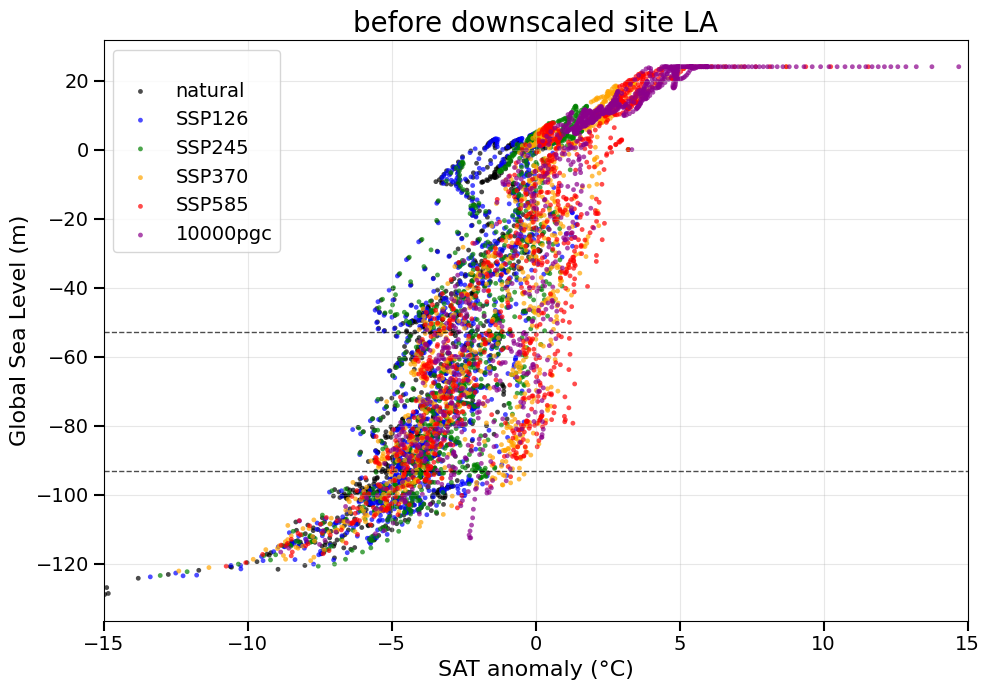

In [23]:
import matplotlib.pyplot as plt

# =========================
# SAT-GSL comparison plot
# =========================
# Uses variables from Cell 1:
# - scenarios, site, member_idx, gsl_by_scenario, load_tas_for_scenario
# Optional: gsl_thresholds

scenario_colors = {
    "natural": "black",
    "SSP126": "blue",
    "SSP245": "green",
    "SSP370": "orange",
    # "SSP460": "yellow",
    # "SSP534": "pink",
    "SSP585": "red",
    "10000pgc": "darkmagenta",
}

fig, ax = plt.subplots(figsize=(10, 7))
# 仅绘制第67个成员（0-based 索引为 66，即 member_idx）
target_member = member_idx  # 这里应为 66

for scen in scenarios:
    gsl_all = np.asarray(gsl_by_scenario[scen], dtype=float)
    tas_all = np.asarray(load_tas_for_scenario(scen, site_name=site), dtype=float)

    m = min(gsl_all.shape[0], tas_all.shape[0])
    if target_member >= m:
        continue

    gsl_series = np.asarray(gsl_all[target_member], dtype=float)
    tas_series = np.asarray(tas_all[target_member], dtype=float)
    n = min(gsl_series.shape[0], tas_series.shape[0])
    gsl_series, tas_series = gsl_series[:n], tas_series[:n]

    ax.scatter(
        tas_series,
        gsl_series,
        s=12,
        alpha=0.7,
        color=scenario_colors.get(scen, None),
        label=scen,
        edgecolors="none",
    )

if "gsl_thresholds" in globals():
    for thr in gsl_thresholds:
        ax.axhline(thr, color="black", linestyle="--", linewidth=1, alpha=0.7)

ax.set_xlabel("SAT anomaly (°C)", fontsize=16)
ax.set_ylabel("Global Sea Level (m)", fontsize=16)
ax.set_title(f" ", fontsize=13)
ax.grid(alpha=0.3)
ax.legend(title=" ", fontsize=14)
ax.set_xlim(-15, 15)
ax.tick_params(axis="both", which="major", labelsize=14, length=7, width=1.5)
ax.tick_params(axis="both", which="minor", length=4, width=1.2)
ax.set_title(
    f"downscaled site {site.lstrip('_')}" if downscaled else f"before downscaled site {site.lstrip('_')}",
    fontsize=20
)

plt.tight_layout()
plt.savefig(f"SAT_GSL_site{site}.png", dpi=300)
plt.show()